In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('mst-benchmarks.csv')

### MST Graph plots

In [3]:
kruskaldata = df.loc[(df[' NodeCount'] == 5000) & (df['Algorithm'] == 'Kruskal')]
primdata = df.loc[(df[' NodeCount'] == 5000) & (df['Algorithm'] == 'Prim')]
kruskaldata = kruskaldata.drop_duplicates(" EdgeCount")
primdata = primdata.drop_duplicates(" EdgeCount")

In [4]:
primdata

,Algorithm,NodeCount,EdgeCount,Distribution,MeanTime,StdDev,MedianTime
6,Prim,5000,25000,DAG,6.201707,0.502636,6.183511
26,Prim,5000,3124375,DENSE,653.278931,5.164800,651.287105
36,Prim,5000,12497500,COMPLETE,1763.790493,20.972597,1753.958971


In [5]:
kruskaldata

,Algorithm,NodeCount,EdgeCount,Distribution,MeanTime,StdDev,MedianTime
7,Kruskal,5000,25000,DAG,17.414452,1.802063,18.287306
27,Kruskal,5000,3124375,DENSE,1997.706378,34.181299,2006.833733
37,Kruskal,5000,12497500,COMPLETE,8393.265245,53.370518,8407.089919


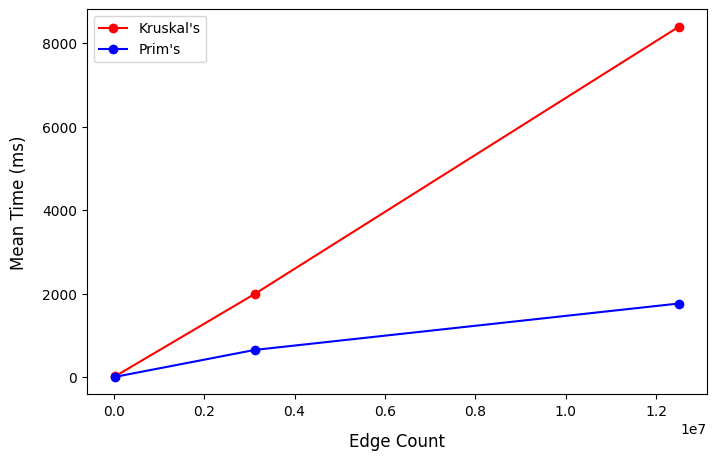

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.set_xlabel("Edge Count", fontsize=12, labelpad=10)
ax.set_ylabel("Mean Time (ms)", fontsize=12, labelpad=10)

ax.plot(
    kruskaldata[" EdgeCount"],
    kruskaldata[" MeanTime"],
    marker="o",
    color="red",
    linestyle="-",
    label="Kruskal's",
)
ax.plot(
    primdata[" EdgeCount"],
    primdata[" MeanTime"],
    marker="o",
    color="blue",
    linestyle="-",
    label="Prim's",
)
ax.legend(loc="upper left", fontsize=10, frameon=True)

> **Note that**: The Kruskal's version should run slower on Dense Graph due to the `O(ELgE)` vs `O((V+E)LgV)` however if we disable the pretest-shuffling the caching of sorted list reduces overhead and thus will lead to comparable or even faster faster execution.

## Single Source Shortest Path

In [ ]:
df = pd.read_csv('general-sssp-benchmarks.csv')
dijkstradata = df.drop_duplicates(' EdgeCount')
dijkstradata = dijkstradata.sort_index(' EdgeCount')

In [15]:
dijkstradata

,Algorithm,NodeCount,EdgeCount,Distribution,MeanTime,StdDev,MedianTime
0,Dijkstra,1000,5000,DAG,0.490339,0.089441,0.473924
1,Dijkstra,2500,12500,DAG,0.912630,0.068887,0.935206
2,Dijkstra,5000,25000,DAG,3.386294,0.972021,3.552260
3,Dijkstra,7500,37500,DAG,11.491816,3.781458,12.216106
4,Dijkstra,10000,50000,DAG,3.119963,0.074372,3.116694
10,Dijkstra,1000,124875,DENSE,15.097641,3.637077,15.803242
11,Dijkstra,2500,780937,DENSE,120.992099,13.399004,114.607021
12,Dijkstra,5000,3124375,DENSE,361.995898,8.321413,360.048844
13,Dijkstra,7500,7030312,DENSE,722.700692,6.468477,719.941040
14,Dijkstra,10000,12498750,DENSE,1324.905815,4.537592,1323.854640


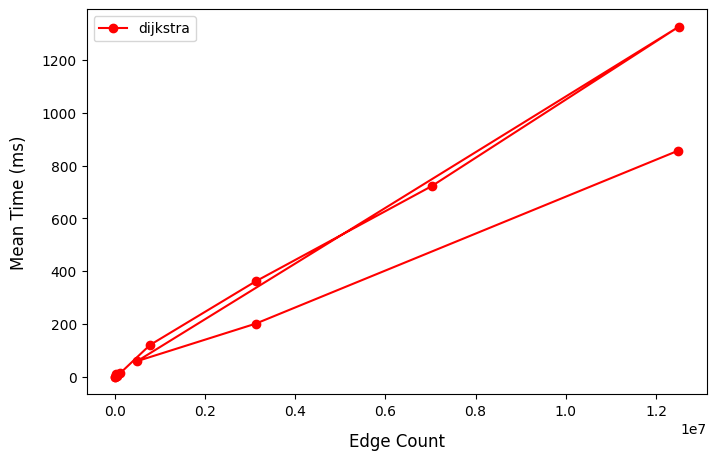

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.set_xlabel("Edge Count", fontsize=12, labelpad=10)
ax.set_ylabel("Mean Time (ms)", fontsize=12, labelpad=10)

ax.plot(
    dijkstradata[" EdgeCount"],
    dijkstradata[" MeanTime"],
    marker="o",
    color="red",
    linestyle="-",
    label="dijkstra",
)
ax.legend(loc="upper left", fontsize=10, frameon=True)

## Dijkstra vs DAG SSSP

In [12]:
df = pd.read_csv('general-sssp-benchmarks.csv')
dijkstradata = df.loc[(df[' Distribution'] == ' DAG')]
dijkstradata = dijkstradata.drop_duplicates(' EdgeCount').sort_values(' EdgeCount')


df = pd.read_csv('dag-sssp-benchmarks.csv')
dagdata = df.loc[(df[ 'Algorithm'] == 'DAG-Topo')]
dagdata = dagdata.drop_duplicates(' EdgeCount').sort_values(' EdgeCount')


In [13]:
dijkstradata

,Algorithm,NodeCount,EdgeCount,Distribution,MeanTime,StdDev,MedianTime
0,Dijkstra,500,2500,DAG,0.547706,0.074056,0.504253
1,Dijkstra,1000,5000,DAG,1.327098,0.069001,1.348390
2,Dijkstra,2500,12500,DAG,2.899000,0.474031,2.879324
3,Dijkstra,5000,25000,DAG,3.431187,0.036867,3.439121
18,Dijkstra,50000,49999,DAG,4.812190,0.630003,4.620893
16,Dijkstra,10000,50000,DAG,14.190283,1.328318,13.929364
17,Dijkstra,20000,100000,DAG,19.789716,2.434682,18.667700
19,Dijkstra,100000,500000,DAG,85.789956,28.929176,70.294902


In [14]:
dagdata

,Algorithm,NodeCount,EdgeCount,MeanTime,StdDev,MedianTime,SpeedupMultiplier
8,DAG-Topo,1000,5000,3.624951,0.120454,3.600862,1.001052
0,DAG-Topo,2500,12500,2.580473,0.187631,2.522084,1.567773
1,DAG-Topo,5000,25000,4.805695,0.109697,4.790468,1.398500
2,DAG-Topo,10000,50000,13.032847,5.909809,12.713534,1.390027
11,DAG-Topo,20000,100000,28.419404,3.433482,29.842018,0.574147
12,DAG-Topo,100000,500000,196.004681,52.911840,198.148058,0.819944


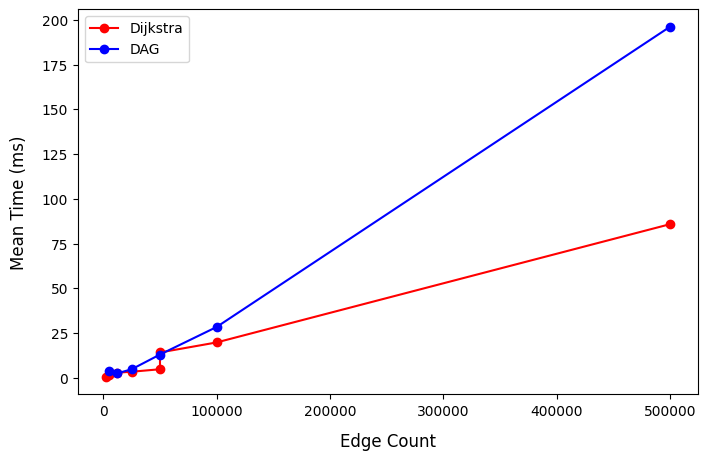

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.set_xlabel("Edge Count", fontsize=12, labelpad=10)
ax.set_ylabel("Mean Time (ms)", fontsize=12, labelpad=10)

ax.plot(
    dijkstradata[" EdgeCount"],
    dijkstradata[" MeanTime"],
    marker="o",
    color="red",
    linestyle="-",
    label="Dijkstra",
)
ax.plot(
    dagdata[" EdgeCount"],
    dagdata[" MeanTime"],
    marker="o",
    color="blue",
    linestyle="-",
    label="DAG",
)
ax.legend(loc="upper left", fontsize=10, frameon=True)